In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

processed_dir = Path("../data/processed")

mx = pd.read_csv(processed_dir / "us_total_mortality_matrix.csv", index_col=0)
log_mx = pd.read_csv(processed_dir / "us_total_log_mortality_matrix.csv", index_col=0)

mx.index = mx.index.astype(int)
mx.columns = mx.columns.astype(int)

log_mx.index = log_mx.index.astype(int)
log_mx.columns = log_mx.columns.astype(int)

print("mx shape:", mx.shape)
print("log_mx shape:", log_mx.shape)

log_mx.head()

mx shape: (111, 92)
log_mx shape: (111, 92)


,1933,1934,1935,1936,1937,1938,1939,1940,1941,1942,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
Age_num,,,,,,,,,,,,,,,,,,,,,
0,-2.792106,-2.681111,-2.788572,-2.768182,-2.792514,-2.849936,-2.930094,-2.923709,-2.949689,-3.029682,...,-5.096193,-5.094234,-5.106541,-5.123188,-5.140630,-5.223024,-5.195219,-5.182492,-5.203007,-5.197929
1,-4.660789,-4.550871,-4.720357,-4.729487,-4.783579,-4.850176,-5.066888,-5.166412,-5.199921,-5.390213,...,-7.787232,-7.804243,-7.819058,-7.844249,-7.819058,-7.904714,-7.816574,-7.712952,-7.749402,-7.836625
2,-5.437350,-5.328364,-5.485611,-5.463664,-5.528737,-5.637152,-5.839946,-5.914874,-5.961906,-6.119753,...,-8.258682,-8.217089,-8.274247,-8.206039,-8.326573,-8.360189,-8.274247,-8.173603,-8.159519,-8.266434
3,-5.775064,-5.735273,-5.815832,-5.859384,-5.912653,-6.013710,-6.168679,-6.317195,-6.332266,-6.392539,...,-8.517193,-8.502305,-8.527244,-8.563237,-8.606024,-8.579069,-8.558015,-8.412833,-8.454218,-8.468403
4,-6.038137,-6.011259,-6.030621,-6.087095,-6.147884,-6.250235,-6.388366,-6.514363,-6.565585,-6.612105,...,-8.811564,-8.721760,-8.791630,-8.804875,-8.838777,-8.881037,-8.734106,-8.697517,-8.727914,-8.685612


In [2]:
a_x = log_mx.mean(axis=1)

a_x.name = "a_x"

a_x.head()

Age_num
0   -4.175754
1   -6.758425
2   -7.244202
3   -7.527367
4   -7.744006
Name: a_x, dtype: float64

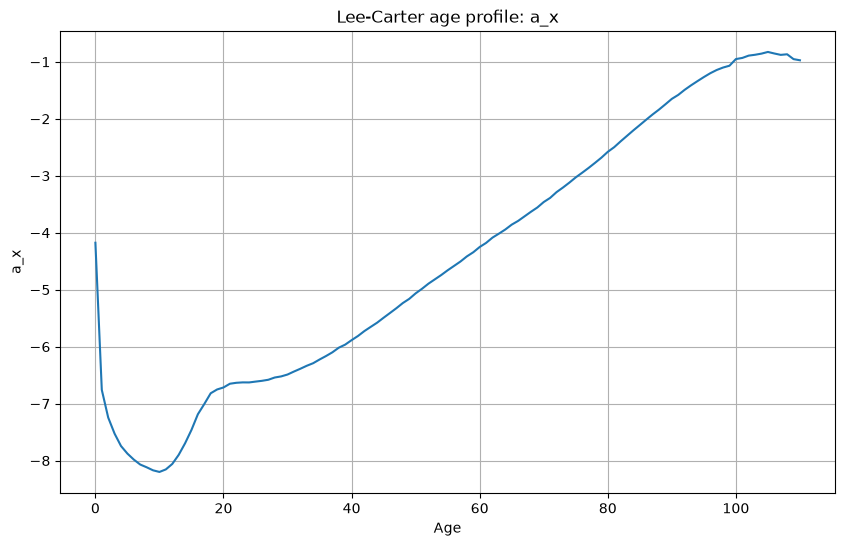

In [3]:
plt.figure(figsize=(10, 6))

plt.plot(a_x.index, a_x.values)

plt.xlabel("Age")
plt.ylabel("a_x")
plt.title("Lee-Carter age profile: a_x")
plt.grid(True)
plt.show()

In [4]:
centered_log_mx = log_mx.sub(a_x, axis=0)

centered_log_mx.head()

,1933,1934,1935,1936,1937,1938,1939,1940,1941,1942,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
Age_num,,,,,,,,,,,,,,,,,,,,,
0,1.383648,1.494642,1.387182,1.407571,1.383240,1.325817,1.245659,1.252044,1.226065,1.146071,...,-0.920440,-0.918481,-0.930787,-0.947435,-0.964877,-1.047271,-1.019466,-1.006738,-1.027254,-1.022176
1,2.097637,2.207554,2.038069,2.028938,1.974846,1.908249,1.691537,1.592013,1.558504,1.368212,...,-1.028807,-1.045818,-1.060633,-1.085824,-1.060633,-1.146289,-1.058149,-0.954527,-0.990977,-1.078200
2,1.806852,1.915838,1.758591,1.780538,1.715465,1.607049,1.404256,1.329328,1.282296,1.124449,...,-1.014481,-0.972887,-1.030045,-0.961837,-1.082371,-1.115988,-1.030045,-0.929402,-0.915317,-1.022233
3,1.752304,1.792094,1.711535,1.667983,1.614714,1.513657,1.358688,1.210173,1.195101,1.134828,...,-0.989826,-0.974937,-0.999876,-1.035870,-1.078657,-1.051701,-1.030648,-0.885466,-0.926851,-0.941036
4,1.705869,1.732747,1.713385,1.656911,1.596121,1.493771,1.355639,1.229643,1.178421,1.131901,...,-1.067558,-0.977755,-1.047624,-1.060869,-1.094771,-1.137031,-0.990100,-0.953511,-0.983908,-0.941606


In [5]:
centered_log_mx.mean(axis=1).head()

Age_num
0   -1.834282e-16
1   -1.004028e-15
2    9.654113e-16
3    1.158494e-16
4    9.267949e-16
dtype: float64

In [6]:
U, s, Vt = np.linalg.svd(centered_log_mx.values, full_matrices=False)

print("U shape:", U.shape)
print("s shape:", s.shape)
print("Vt shape:", Vt.shape)

U shape: (111, 92)
s shape: (92,)
Vt shape: (92, 92)


In [7]:
b_x_raw = U[:, 0]
k_t_raw = s[0] * Vt[0, :]

b_x = pd.Series(b_x_raw, index=log_mx.index, name="b_x")
k_t = pd.Series(k_t_raw, index=log_mx.columns, name="k_t")

b_x.head(), k_t.head()

(Age_num
 0   -0.187656
 1   -0.218307
 2   -0.196548
 3   -0.192682
 4   -0.193694
 Name: b_x, dtype: float64,
 1933   -8.410175
 1934   -8.556881
 1935   -8.373228
 1936   -8.543293
 1937   -8.130892
 Name: k_t, dtype: float64)

In [8]:
# Constraint 1: sum of b_x equals 1
scale = b_x.sum()

b_x = b_x / scale
k_t = k_t * scale

# Constraint 2: mean of k_t equals 0
k_mean = k_t.mean()

k_t = k_t - k_mean
a_x = a_x + b_x * k_mean

print("sum(b_x):", b_x.sum())
print("mean(k_t):", k_t.mean())

sum(b_x): 1.0000000000000002
mean(k_t): -3.089316242435218e-16


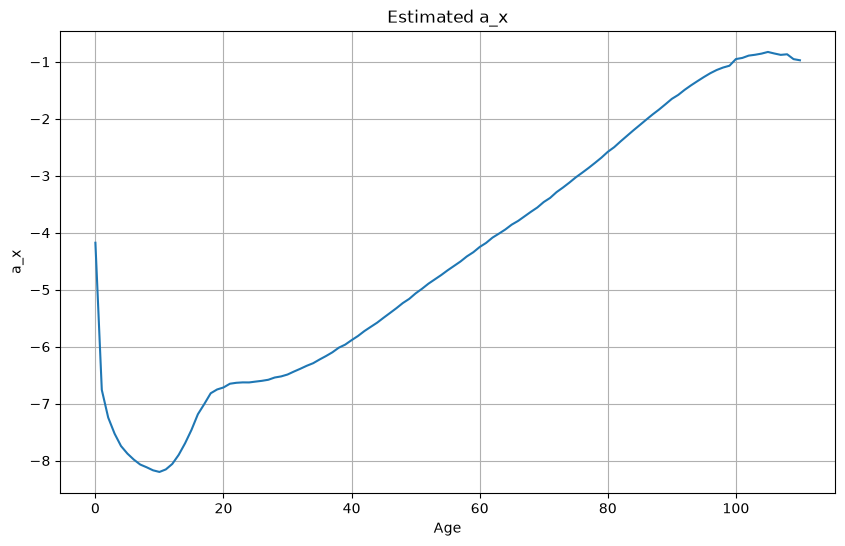

In [9]:
plt.figure(figsize=(10, 6))
plt.plot(a_x.index, a_x.values)
plt.xlabel("Age")
plt.ylabel("a_x")
plt.title("Estimated a_x")
plt.grid(True)
plt.show()

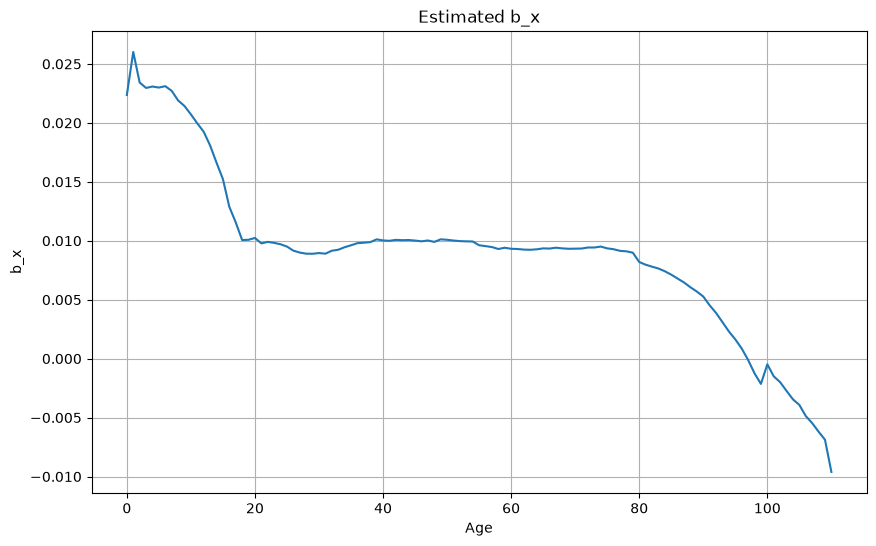

In [10]:
plt.figure(figsize=(10, 6))
plt.plot(b_x.index, b_x.values)
plt.xlabel("Age")
plt.ylabel("b_x")
plt.title("Estimated b_x")
plt.grid(True)
plt.show()

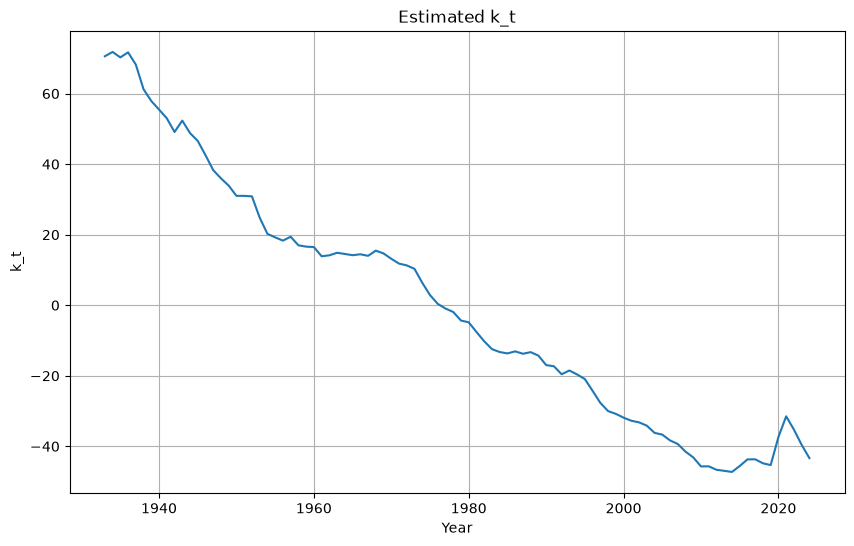

In [11]:
plt.figure(figsize=(10, 6))
plt.plot(k_t.index, k_t.values)
plt.xlabel("Year")
plt.ylabel("k_t")
plt.title("Estimated k_t")
plt.grid(True)
plt.show()

In [12]:
fitted_log_mx = pd.DataFrame(
    np.outer(b_x.values, k_t.values),
    index=log_mx.index,
    columns=log_mx.columns
)

fitted_log_mx = fitted_log_mx.add(a_x, axis=0)

fitted_log_mx.head()

,1933,1934,1935,1936,1937,1938,1939,1940,1941,1942,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
Age_num,,,,,,,,,,,,,,,,,,,,,
0,-2.597534,-2.570003,-2.604467,-2.572553,-2.649943,-2.806519,-2.881106,-2.935336,-2.990430,-3.077496,...,-5.195301,-5.153258,-5.152485,-5.178074,-5.189227,-5.011623,-4.880208,-4.964104,-5.060797,-5.145101
1,-4.922426,-4.890399,-4.930492,-4.893366,-4.983396,-5.165547,-5.252316,-5.315404,-5.379497,-5.480784,...,-7.944501,-7.895591,-7.894691,-7.924460,-7.937435,-7.730821,-7.577942,-7.675541,-7.788028,-7.886101
2,-5.591201,-5.562366,-5.598463,-5.565037,-5.646094,-5.810089,-5.888210,-5.945010,-6.002714,-6.093906,...,-8.312059,-8.268023,-8.267213,-8.294016,-8.305697,-8.119677,-7.982035,-8.069907,-8.171182,-8.259480
3,-5.906874,-5.878606,-5.913993,-5.881225,-5.960687,-6.121458,-6.198042,-6.253725,-6.310295,-6.399693,...,-8.574224,-8.531055,-8.530260,-8.556536,-8.567987,-8.385625,-8.250690,-8.336834,-8.436117,-8.522679
4,-6.115007,-6.086591,-6.122164,-6.089223,-6.169103,-6.330717,-6.407703,-6.463679,-6.520545,-6.610413,...,-8.796357,-8.752961,-8.752163,-8.778576,-8.790088,-8.606769,-8.471126,-8.557721,-8.657526,-8.744541


In [13]:
residual = log_mx - fitted_log_mx

rmse = np.sqrt(np.mean(residual.values ** 2))

variance_explained = s[0] ** 2 / np.sum(s ** 2)

print("RMSE:", rmse)
print("Variance explained by first component:", variance_explained)

RMSE: 0.1325000718735725
Variance explained by first component: 0.8969018779420149


In [14]:
print("sum(b_x):", b_x.sum())
print("mean(k_t):", k_t.mean())
print("RMSE:", rmse)
print("Variance explained:", variance_explained)

display(a_x.head())
display(b_x.head())
display(k_t.head())

sum(b_x): 1.0000000000000002
mean(k_t): -3.089316242435218e-16
RMSE: 0.1325000718735725
Variance explained: 0.8969018779420149


Age_num
0   -4.175754
1   -6.758425
2   -7.244202
3   -7.527367
4   -7.744006
dtype: float64

Age_num
0    0.022364
1    0.026016
2    0.023423
3    0.022963
4    0.023083
Name: b_x, dtype: float64

1933    70.571104
1934    71.802138
1935    70.261074
1936    71.688118
1937    68.227601
Name: k_t, dtype: float64

The initial model was estimated using ages 0–110. However, the estimated \(b_x\) becomes unstable at very high ages, likely due to sparse exposure and the open-ended 110+ age group. Therefore, I also estimate a refined model using ages 0–100.

## Refined Lee-Carter Model: Ages 0–100

In [16]:
# Restrict the model to ages 0 through 100
log_mx_100 = log_mx.loc[0:100]

# Estimate a_x
a_x_100 = log_mx_100.mean(axis=1)
a_x_100.name = "a_x"

# Center the log mortality matrix
centered_100 = log_mx_100.sub(a_x_100, axis=0)

# SVD
U_100, s_100, Vt_100 = np.linalg.svd(centered_100.values, full_matrices=False)

# Extract raw b_x and k_t
b_x_100 = pd.Series(U_100[:, 0], index=log_mx_100.index, name="b_x")
k_t_100 = pd.Series(s_100[0] * Vt_100[0, :], index=log_mx_100.columns, name="k_t")

# Normalize: sum b_x = 1
scale_100 = b_x_100.sum()
b_x_100 = b_x_100 / scale_100
k_t_100 = k_t_100 * scale_100

# Normalize: mean k_t = 0
k_mean_100 = k_t_100.mean()
k_t_100 = k_t_100 - k_mean_100
a_x_100 = a_x_100 + b_x_100 * k_mean_100

# Diagnostics
fitted_log_mx_100 = pd.DataFrame(
    np.outer(b_x_100.values, k_t_100.values),
    index=log_mx_100.index,
    columns=log_mx_100.columns
).add(a_x_100, axis=0)

residual_100 = log_mx_100 - fitted_log_mx_100

rmse_100 = np.sqrt(np.mean(residual_100.values ** 2))
variance_explained_100 = s_100[0] ** 2 / np.sum(s_100 ** 2)

print("sum(b_x_100):", b_x_100.sum())
print("mean(k_t_100):", k_t_100.mean())
print("RMSE:", rmse_100)
print("Variance explained:", variance_explained_100)

sum(b_x_100): 1.0
mean(k_t_100): 5.406303424261632e-16
RMSE: 0.09165881072410072
Variance explained: 0.9514968539934147


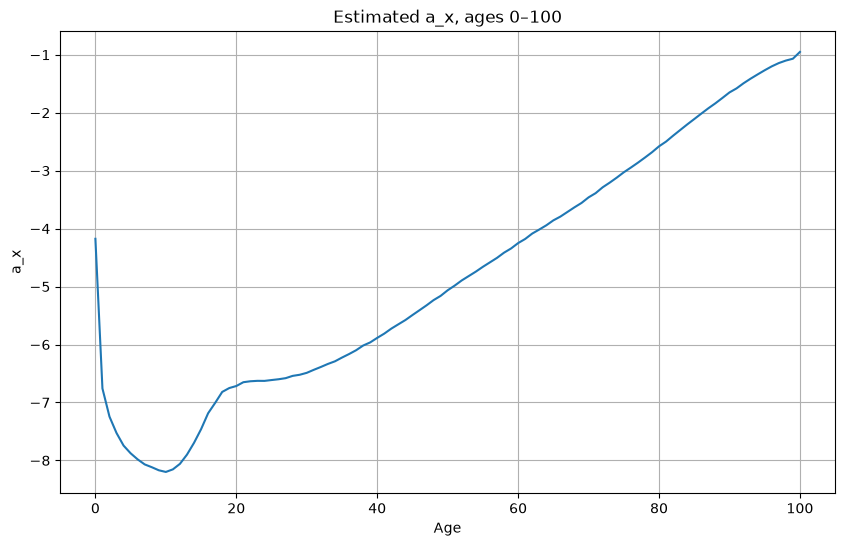

In [17]:
plt.figure(figsize=(10, 6))
plt.plot(a_x_100.index, a_x_100.values)
plt.xlabel("Age")
plt.ylabel("a_x")
plt.title("Estimated a_x, ages 0–100")
plt.grid(True)
plt.show()

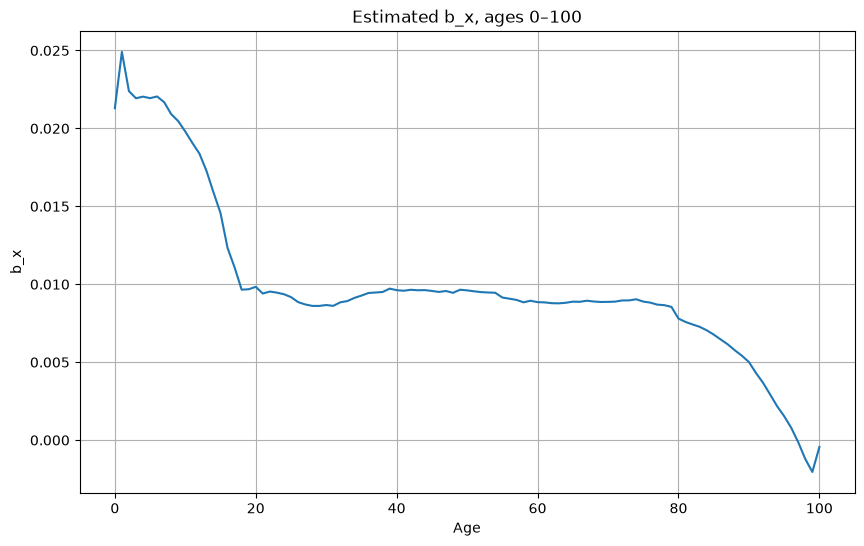

In [18]:
plt.figure(figsize=(10, 6))
plt.plot(b_x_100.index, b_x_100.values)
plt.xlabel("Age")
plt.ylabel("b_x")
plt.title("Estimated b_x, ages 0–100")
plt.grid(True)
plt.show()

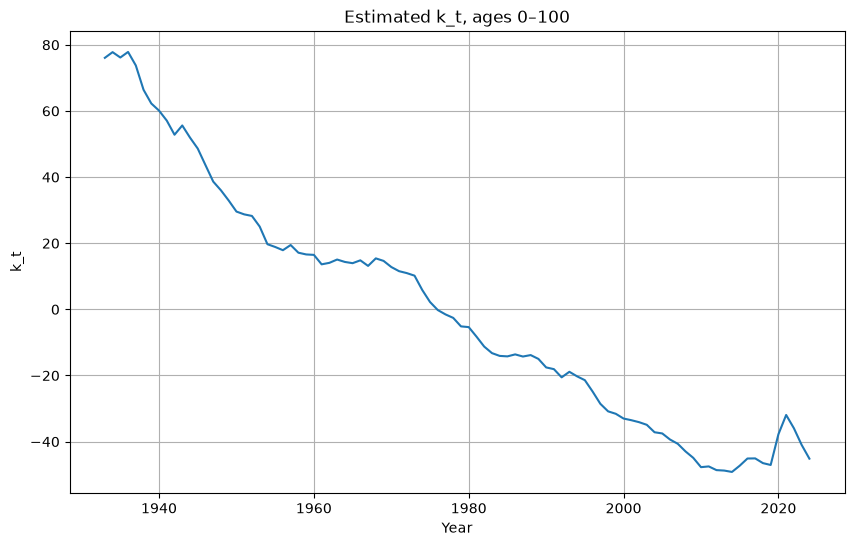

In [19]:
plt.figure(figsize=(10, 6))
plt.plot(k_t_100.index, k_t_100.values)
plt.xlabel("Year")
plt.ylabel("k_t")
plt.title("Estimated k_t, ages 0–100")
plt.grid(True)
plt.show()

In [20]:
# Save refined Lee-Carter parameters

params_dir = Path("../data/processed")

a_x_100.to_csv(params_dir / "a_x_100.csv")
b_x_100.to_csv(params_dir / "b_x_100.csv")
k_t_100.to_csv(params_dir / "k_t_100.csv")

print("Saved refined Lee-Carter parameters.")

Saved refined Lee-Carter parameters.


## Conclusion

The refined Lee-Carter model using ages 0–100 produces stable age-specific parameters and a clear downward trend in the mortality index. The first SVD component explains approximately 89.7% of the centered log-mortality variation, supporting the use of a one-factor mortality trend model for forecasting.